# 06 - Détection des patterns Smart Money Concepts

## Objectif

Détecter automatiquement les patterns SMC avec des Swing Highs et Swing Lows.

Les patterns détectés sont :

- Swing High
- Swing Low
- Bullish BOS
- Bearish BOS
- Bullish CHOCH
- Bearish CHOCH
- Bullish FVG
- Bearish FVG

Ces variables seront utilisées dans le modèle de Machine Learning.

## 2. Importation des bibliothèques

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Chargement des données enrichies

In [27]:
PROJECT_ROOT = Path.cwd().parent

CLUSTER_DIR = PROJECT_ROOT / "data" / "clustered"

gold = pd.read_csv(
    CLUSTER_DIR / "gold_clustered.csv"
)

display(gold.head())

,Datetime,Close,High,Low,Open,Volume,Ticker,EMA20,EMA50,RSI,ATR,Target,EMA200,Return,Volatility,Market_Regime,Hour,DayOfWeek,Timeframe,Cluster
0,2024-05-31 01:00:00+00:00,2367.899902,2368.800049,2344.800049,2367.500000,3302,GC=F,2363.060853,2360.692465,57.070461,28.528582,0,2359.151629,0.000127,0.002981,Bull,1,4,H1,1
1,2024-05-31 02:00:00+00:00,2363.899902,2369.000000,2342.000000,2367.800049,2571,GC=F,2363.150699,2360.907379,58.701180,28.428571,0,2359.390873,-0.001689,0.002810,Bull,2,4,H1,1
2,2024-05-31 03:00:00+00:00,2364.100098,2364.699951,2338.800049,2363.800049,5985,GC=F,2363.251172,2361.115523,51.963800,27.671422,1,2359.618928,0.000085,0.002747,Bull,3,4,H1,1
3,2024-05-31 04:00:00+00:00,2365.100098,2366.899902,2342.899902,2364.800049,3149,GC=F,2363.444790,2361.368713,40.225781,27.057129,0,2359.874531,0.000423,0.001563,Bull,4,4,H1,2
4,2024-05-31 05:00:00+00:00,2363.500000,2365.600098,2341.000000,2365.000000,2597,GC=F,2363.450517,2361.500924,45.726567,26.478568,1,2360.037615,-0.000677,0.001575,Bull,5,4,H1,2


In [38]:
# 4. Détection des Swing Highs et Swing Lows

## Détection des Swing Highs et Swing Lows

Un Swing High est un sommet local.

Un Swing Low est un creux local.

Ces niveaux servent à détecter les cassures de structure.

In [53]:
lookback = 20

gold["Swing_High"] = np.where(
    gold["High"] == gold["High"].rolling(
        window=lookback * 2 + 1,
        center=True
    ).max(),
    1,
    0
)

gold["Swing_Low"] = np.where(
    gold["Low"] == gold["Low"].rolling(
        window=lookback * 2 + 1,
        center=True
    ).min(),
    1,
    0
)

## 5. Création des derniers niveaux de structure

In [54]:
gold["Last_Swing_High"] = gold["High"].where(
    gold["Swing_High"] == 1
).ffill()

gold["Last_Swing_Low"] = gold["Low"].where(
    gold["Swing_Low"] == 1
).ffill()

# 6. Détection des BOS

## Break Of Structure

Un BOS confirme souvent la continuité de la tendance.

Bullish BOS : le prix ferme au-dessus du dernier Swing High.

Bearish BOS : le prix ferme en dessous du dernier Swing Low.

In [55]:
gold["BOS_Bullish"] = np.where(
    gold["Close"] > gold["Last_Swing_High"].shift(1),
    1,
    0
)

gold["BOS_Bearish"] = np.where(
    gold["Close"] < gold["Last_Swing_Low"].shift(1),
    1,
    0
)

## 7. Détection des CHOCH

In [58]:
#7. Détection des CHOCH

Un CHOCH indique un possible changement de tendance.

Bullish CHOCH : le marché était bearish et casse un Swing High.

Bearish CHOCH : le marché était bullish et casse un Swing Low.

In [59]:
gold["CHOCH_Bullish"] = np.where(
    (gold["Market_Regime"].shift(1) == "Bear") &
    (gold["Close"] > gold["Last_Swing_High"].shift(1)),
    1,
    0
)

gold["CHOCH_Bearish"] = np.where(
    (gold["Market_Regime"].shift(1) == "Bull") &
    (gold["Close"] < gold["Last_Swing_Low"].shift(1)),
    1,
    0
)

## 8. Détection des FVG

## Fair Value Gap

Un FVG représente un déséquilibre entre trois bougies.

Bullish FVG : Low actuel > High deux bougies avant.

Bearish FVG : High actuel < Low deux bougies avant.

In [60]:
gold["FVG_Bullish"] = np.where(
    gold["Low"] > gold["High"].shift(2),
    1,
    0
)

gold["FVG_Bearish"] = np.where(
    gold["High"] < gold["Low"].shift(2),
    1,
    0
)

## 9. Vérification des résultats

In [61]:
patterns = [
    "Swing_High",
    "Swing_Low",
    "BOS_Bullish",
    "BOS_Bearish",
    "CHOCH_Bullish",
    "CHOCH_Bearish",
    "FVG_Bullish",
    "FVG_Bearish"
]

gold[patterns].sum()

Swing_High        183
Swing_Low         189
BOS_Bullish      2258
BOS_Bearish       548
CHOCH_Bullish      11
CHOCH_Bearish      15
FVG_Bullish      1232
FVG_Bearish       899
dtype: int64

## 10. Visualisation

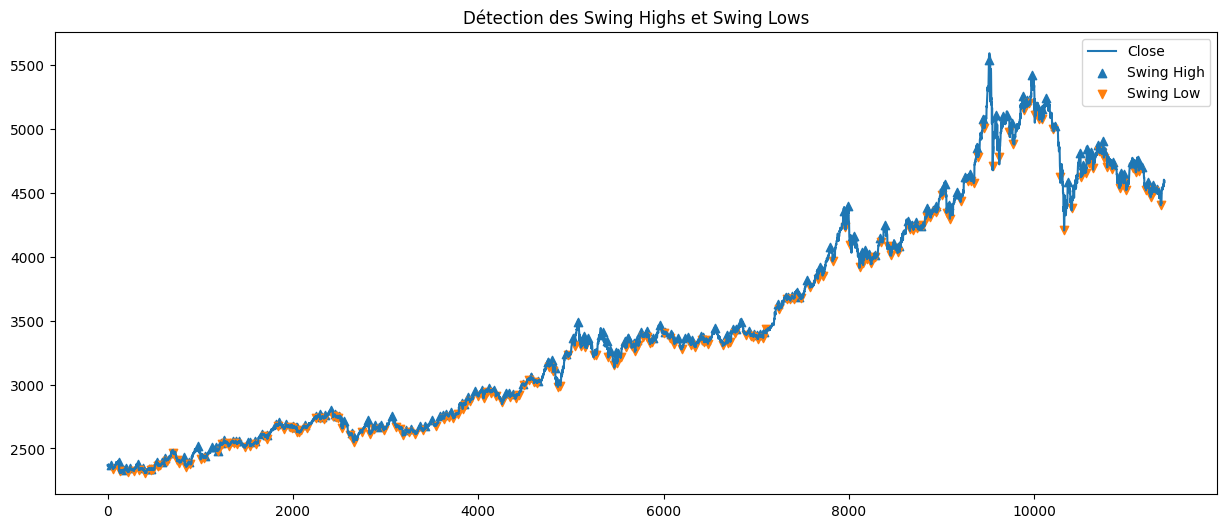

In [62]:
plt.figure(figsize=(15, 6))

plt.plot(
    gold["Close"],
    label="Close"
)

swing_highs = gold[gold["Swing_High"] == 1]
swing_lows = gold[gold["Swing_Low"] == 1]

plt.scatter(
    swing_highs.index,
    swing_highs["Close"],
    marker="^",
    label="Swing High"
)

plt.scatter(
    swing_lows.index,
    swing_lows["Close"],
    marker="v",
    label="Swing Low"
)

plt.title("Détection des Swing Highs et Swing Lows")
plt.legend()
plt.show()

In [63]:
## 11. Sauvegarde

In [51]:
PATTERN_DIR = PROJECT_ROOT / "data" / "patterns"

PATTERN_DIR.mkdir(exist_ok=True)

gold.to_csv(
    PATTERN_DIR / "gold_patterns.csv",
    index=False
)

## Résumé

Les patterns SMC ont été détectés avec une approche basée sur les Swing Highs et Swing Lows.

Variables créées :

- Swing_High
- Swing_Low
- Last_Swing_High
- Last_Swing_Low
- BOS_Bullish
- BOS_Bearish
- CHOCH_Bullish
- CHOCH_Bearish
- FVG_Bullish
- FVG_Bearish

Le fichier généré est :

data/patterns/gold_patterns.csv

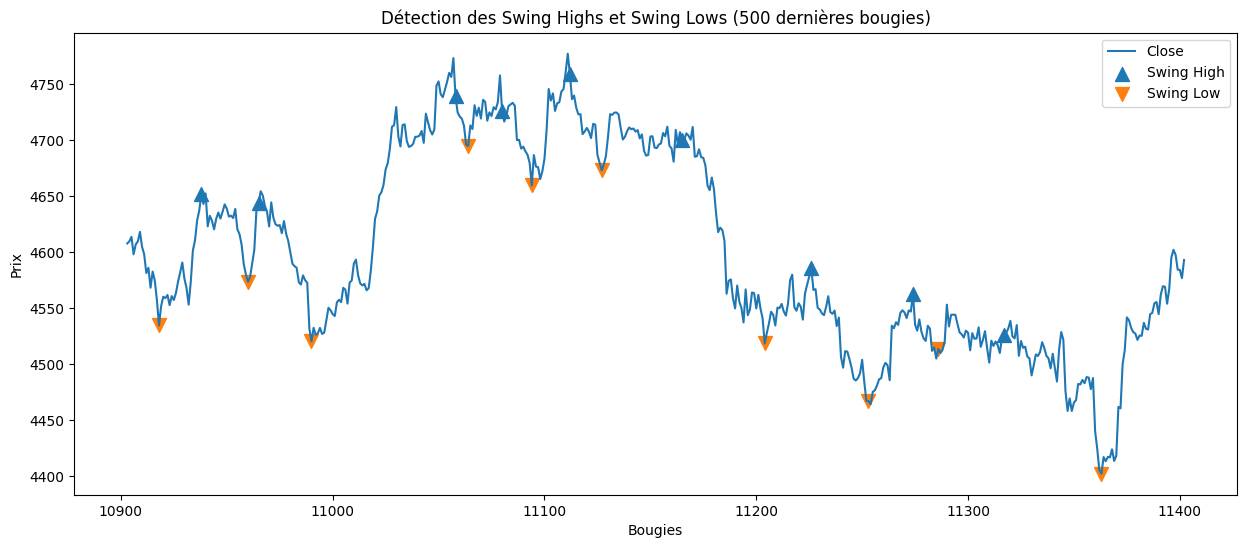

In [64]:
# Sélection des 500 dernières bougies
gold_plot = gold.tail(500)

plt.figure(figsize=(15,6))

plt.plot(
    gold_plot.index,
    gold_plot["Close"],
    label="Close"
)

# Swing Highs
swing_highs = gold_plot[
    gold_plot["Swing_High"] == 1
]

plt.scatter(
    swing_highs.index,
    swing_highs["Close"],
    marker="^",
    s=100,
    label="Swing High"
)

# Swing Lows
swing_lows = gold_plot[
    gold_plot["Swing_Low"] == 1
]

plt.scatter(
    swing_lows.index,
    swing_lows["Close"],
    marker="v",
    s=100,
    label="Swing Low"
)

plt.title(
    "Détection des Swing Highs et Swing Lows (500 dernières bougies)"
)

plt.xlabel("Bougies")
plt.ylabel("Prix")

plt.legend()

plt.show()

In [65]:
print(
    "Nombre de Swing Highs :",
    gold_plot["Swing_High"].sum()
)

print(
    "Nombre de Swing Lows :",
    gold_plot["Swing_Low"].sum()
)

Nombre de Swing Highs : 9
Nombre de Swing Lows : 10
